# Classifying the MNIST Data Using Log Likelihood
While classification using machine learning algrithms have gained sufficient sophistication over the years, underlying all of them lies the concept of hypothesis testing and rigourous statistics. This tutorial will show you exactly how by looking at the MNIST dataset. In the process we hope to illuminate how hypothesis testing is a statement regarding geometry of the likelihood phase space.

The MNIST dataset is a dataset of 60,000 training (10,000 testing) images of handwritten numbers between 0 and 9. Each image consists of $28\times 28$ grayscale pixels.

The MNIST dataset can be downloaded via any standard ML library. We will use pytorch for this example. Use the code below to download it.

In [1]:
# Import torch for working with standard pytorch tensors
import torch

# Transformations are used to preprocess images before they are returned
import torchvision.transforms as transforms

# DataLoader can later be used to iterate through the dataset in batches
from torch.utils.data import DataLoader

# Import the MNIST handwritten digit dataset
from torchvision.datasets import MNIST

# Convert PIL images to PyTorch tensors.
# Pixel values originally lie between 0 and 255 and are scaled to [0, 1].
transform = transforms.ToTensor()

# The training set contains 60,000 labeled handwritten digit images.
train_dataset = MNIST(
    root='./datasets',      # Directory where the dataset will be stored
    train=True,             # Select the training dataset
    download=True,          # Download the dataset if it is not already present
    transform=transform     # Apply the tensor conversion to every image
)

# The test set contains 10,000 images used for evaluating performance.
test_dataset = MNIST(
    root='./datasets',      # Directory where the dataset will be stored
    train=False,            # Select the test dataset
    download=True,          # Download if not already available
    transform=transform     # Convert images to tensors
)

# Create DataLoaders for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=500, num_workers=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=500, num_workers=4, shuffle=False)

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.75MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 148kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.52MB/s]


You should have a feel for what the data represent. Fill the code block below to check the shape of image and label and plot the gray scale image (use 'gray_r' cmap).

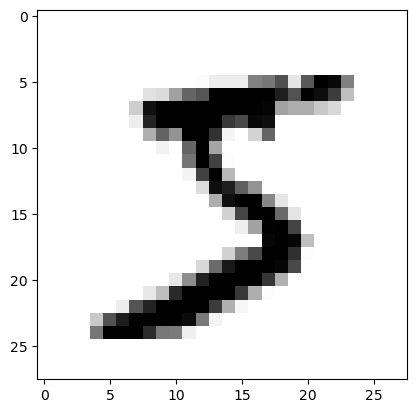

In [2]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

### YOUR CODE HERE
plt.imshow(image.squeeze(), cmap='gray_r')


## Understanding Pixel Probability Mass Function (PPMF)

Now suppose an image is $x$ and the class is $c\in\{0,\cdots,9\}$. Then for each digit you will first estimate $P(x|c)$ from the training set. Then first classify using,

$$\hat{c}=\argmax_c \log[P(x|c)P(c)]$$

Note that if all classes are equally likely,

$$\hat{c}=\argmax_c \log P(x|c)$$

We will assume the simplest probability distribution, i.e, Bernoulli (you can work out the Gaussian case on your own). Then for each digit and each pixel we first convert the gray scale to binary so that the pixel probability mass function becomes,

$$p_{ij}^{(c)}=P(x_{ij}=1|c)$$

Thus for each number we have a $28\times 28$ probability map. Your task is to figure out this map for each digit. Write a function to print a $(28,28)$ tensor that stores the corresponding active pixel probability value (take a threshold of 0.5 on the grayscale for this).

In [3]:
from tqdm import tqdm

def estimate_PPMF(train_loader, c):
    """
    Return the probability that each pixel is active and the total samples given class label c.
    Output shape of PPD should be (28,28).
    """
    active_sample_map = torch.zeros((1, 28, 28)) # Store the active pixel counts for class c
    all_sample_c = 0                             # Store the total number of samples for class c
    for images, labels in tqdm(train_loader):
        ### YOUR CODE HERE
        mask = (labels == c)
        active_sample_map += torch.sum(torch.round(images[mask]), dim=0)
        all_sample_c += mask.sum()
        
        if all_sample_c == 0:
            raise ValueError(f"No samples found for class {c}")
        
    active_sample_map = active_sample_map.squeeze(0)
    return (active_sample_map + 1) / (all_sample_c + 2), all_sample_c

Notice that to calculate the probability we used Laplace smoothing,

$$p_{ij}^{(c)}=\frac{\text{active} + \alpha}{\text{total} + K\alpha}$$

where $K$ is the dimension (here its 2) and $\alpha$ represents the smoothing parameter taken to be 1.

Now that you have the PPMF try plotting the image for all the labels!

100%|██████████| 120/120 [00:05<00:00, 20.25it/s]


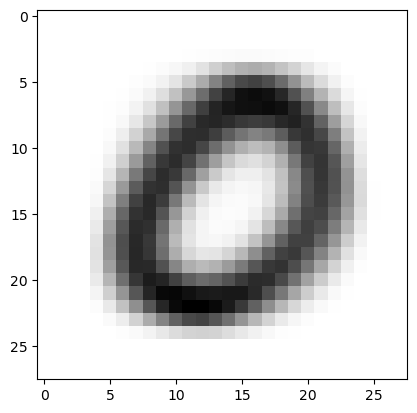

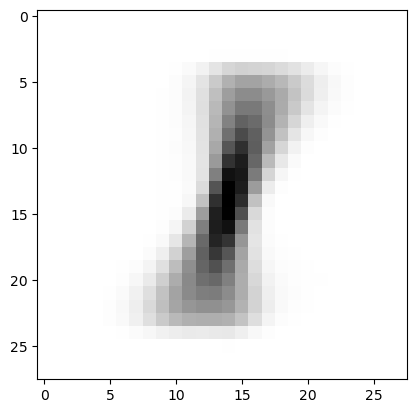

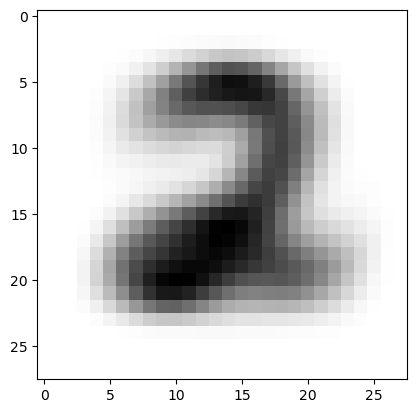

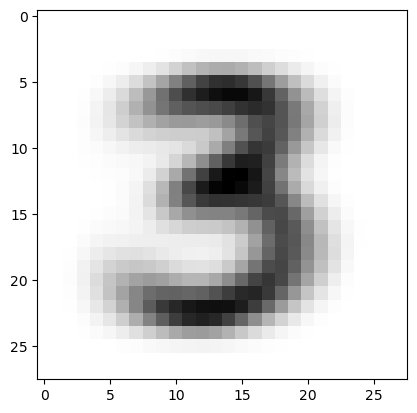

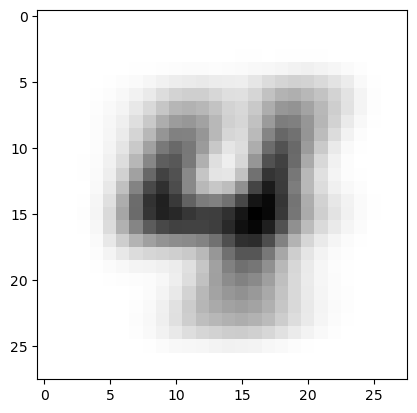

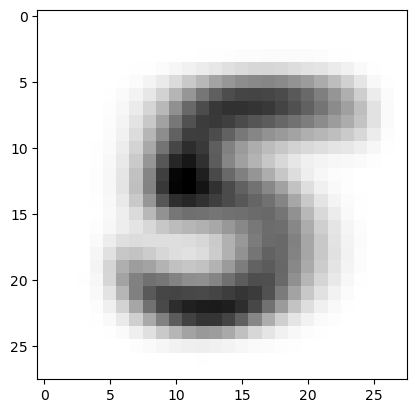

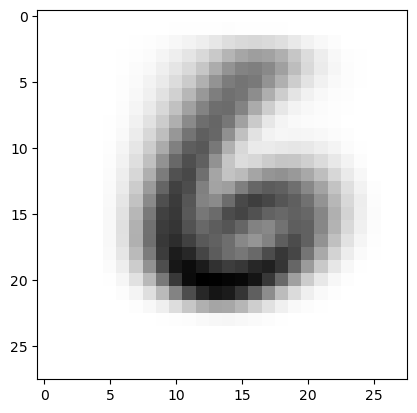

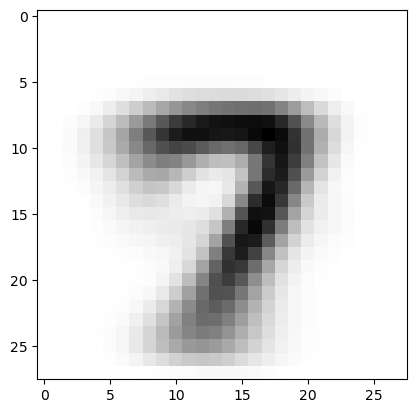

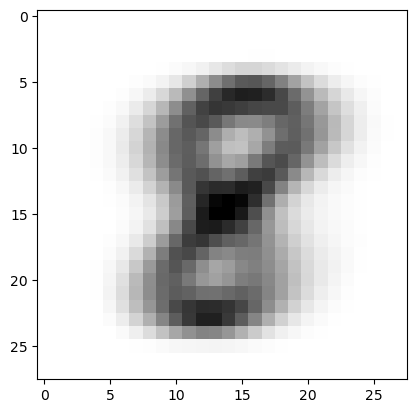

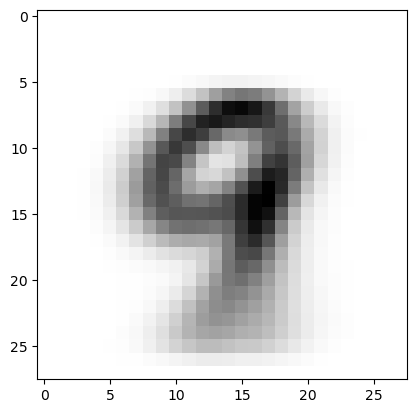

In [4]:
### YOUR CODE HERE
zero_PPMF, zero_num_sample = estimate_PPMF(train_loader, 0)
one_PPMF, one_num_sample = estimate_PPMF(train_loader, 1)
two_PPMF, two_num_sample = estimate_PPMF(train_loader, 2)
three_PPMF, three_num_sample = estimate_PPMF(train_loader, 3)
four_PPMF, four_num_sample = estimate_PPMF(train_loader, 4)
five_PPMF, five_num_sample = estimate_PPMF(train_loader, 5)
six_PPMF, six_num_sample = estimate_PPMF(train_loader, 6)
seven_PPMF, seven_num_sample = estimate_PPMF(train_loader, 7)
eight_PPMF, eight_num_sample = estimate_PPMF(train_loader, 8)
nine_PPMF, nine_num_sample = estimate_PPMF(train_loader, 9)

plt.imshow(zero_PPMF, cmap='gray_r')
plt.show()
plt.imshow(one_PPMF, cmap='gray_r')
plt.show()
plt.imshow(two_PPMF, cmap='gray_r')
plt.show()
plt.imshow(three_PPMF, cmap='gray_r')
plt.show()
plt.imshow(four_PPMF, cmap='gray_r')
plt.show()
plt.imshow(five_PPMF, cmap='gray_r')
plt.show()
plt.imshow(six_PPMF, cmap='gray_r')
plt.show()
plt.imshow(seven_PPMF, cmap='gray_r')
plt.show()
plt.imshow(eight_PPMF, cmap='gray_r')
plt.show()
plt.imshow(nine_PPMF, cmap='gray_r')
plt.show()

## Compute Log-Likelihood

The likelihood is just the cross entropy and can be written as,

$$P(x|c) = \prod_{ij}(p_{ij}^{(c)})^{x_{ij}}(1-p_{ij}^{(c)})^{1-x_{ij}}$$

Of course this only holds if the distribution of digits is uniform which you should check! Then the log likelihood follows,

$$\log P(x|c) = \sum_{ij}x_{ij}\log p_{ij}^{(c)} + (1 - x_{ij})\log(1 - p_{ij}^{(c)})$$

So now plot the digit distribution!

(0.0, 8000.0)

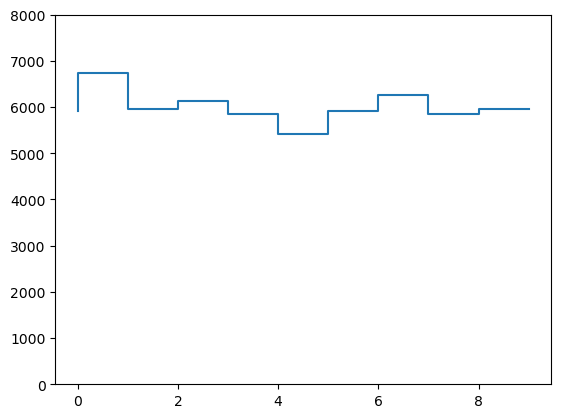

In [5]:
### YOUR CODE HERE
count = [zero_num_sample,one_num_sample,two_num_sample,three_num_sample,four_num_sample,five_num_sample,
         six_num_sample,seven_num_sample,eight_num_sample,nine_num_sample]
label = [0,1,2,3,4,5,6,7,8,9]
plt.step(label,count)
plt.ylim([0,8000])

You will see that the distribution is almost uniform. However had the distribution been anything non-uniform, it would have been a challenge to model the prior properly! This is because we are looking at ensemble averages to gauge out global structures. Note that this is usually where completely frequentist ML algorithm like BDT or neural networks will shine because at the sample level, there are local structures that these models are able to capture successfully. Alright coming back to the tutorial, write down the code for the log-likelihood!

In [6]:
def combine_PPMF(train_loader):
    ''' You need to combine PPMF for every class label and create a tensor
        of shape (10,28,28)
    '''
    PPMF_all = []
    for c in range(10):
        ### YOUR CODE HERE
        PPMF, samples = estimate_PPMF(train_loader, c)
        PPMF_all.append(PPMF.unsqueeze(0))
    return torch.cat(PPMF_all)
    
def log_likelihood(test_loader, combined_PPMF):
    ''' Use your combined PPMF to calculate loglikelihood for every image and
        every label. Thus the output tensor will have a shape of (500, 10).
        Also return the labels to compare later.
    '''
    sample_ll = []
    all_labels = []
    for images, labels in tqdm(test_loader):
        ### YOUR CODE HERE
        PPMF = combined_PPMF.unsqueeze(0).repeat(images.shape[0],1,1,1)
        x = torch.round(images).repeat(1,10,1,1)
        sample_ll.append(torch.sum(x * torch.log(PPMF) + (1 - x) * torch.log(1 - PPMF), dim=(2,3)))
        all_labels.append(labels)
    
    sample_ll = torch.cat(sample_ll)
    all_labels = torch.cat(all_labels)
    return sample_ll, all_labels

## Validation
If you're confident about your code try running the blocks below to calculate the predicted label $\hat{c}$ and other relevant metrics.

In [7]:
all_PPMF = combine_PPMF(train_loader)
loglikelihood, labels = log_likelihood(test_loader, all_PPMF)
pred = torch.argmax(loglikelihood, dim=1)

100%|██████████| 20/20 [00:04<00:00,  4.05it/s]


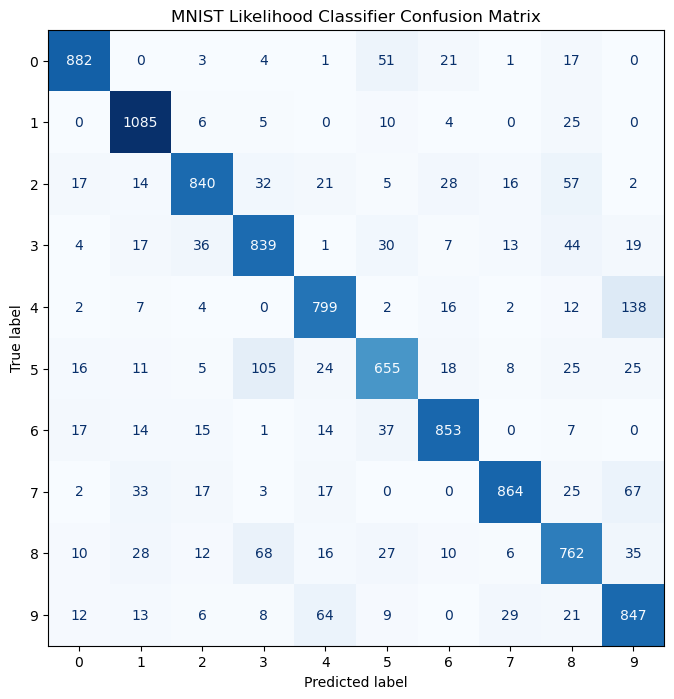

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(labels.numpy(), pred.numpy())

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("MNIST Likelihood Classifier Confusion Matrix")
plt.show()

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

accuracy = accuracy_score(labels, pred)
precision = precision_score(labels, pred, average="weighted")
recall = recall_score(labels, pred, average="weighted")
f1 = f1_score(labels, pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8426
Precision: 0.8447
Recall   : 0.8426
F1 Score : 0.8427


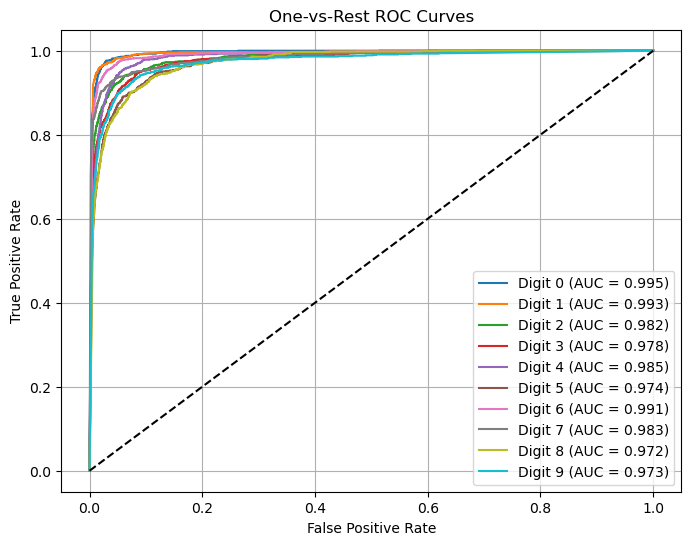

In [10]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true = label_binarize(labels.numpy(), classes=range(10))

### Convert log-likelihoods to probabilities
scores = torch.softmax(loglikelihood, dim=1).numpy()

plt.figure(figsize=(8, 6))

for i in range(10):
    fpr, tpr, _ = roc_curve(y_true[:, i], scores[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Digit {i} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

Now assuming you did everything correctly you have just constructed the Bernoulli Naive Bayes classifier (BNBC). What you will observe now is that numbers that have very good AUC score are $0,1,6$ while numbers like $3, 5, 8, 9$ are slightly worse. This is because (BNBC) looks at the ensemble averages of hand written number and so numbers which are globally distinctive are easier to classify. On the other hand we can see that $8$, $5$ and $3$ look similar globally so the classifier struggle. You can get a feel for this by looking at the PPMF image plots you generated earlier!

## Hypothesis Testing Between Two Digits

Previously we used the principle of maximum likelihood over the space of label class $c$. Now lets look at the entire sample space of log-likelihoods to understand how it varies. To simplify life we will consider only two numbers say $c\in\{3,8\}$ and try to visualise how seperated the log-likelihoods of $8$ is from $3$. Essentially in the space of probability distribution, we are asking what is the distance between $8$ and $3$ ince we have encoded the labels directly to the PPMF. This is the crux of hypothesis testing! In an ideal world if the PPMF of $3$ and $8$ were same (obviously BNBC would suggest they are the same number) the ratio of likelihood would become 1 and hence the test statistics would become,

$$q = \log\frac{P(x|8)}{P(x|3)} = \log P(x|8) - \log P(x|3) = 0$$

So any deviation of $q$ from zero suggests the two hypothesis must be different. In fact the more a number is looking like $3$ the closer it will be to $P(x|3)$ in the space of PPMFs, and $q$ should be negative, and vice versa for $8$.

Now with all that said your next task is to calculate $q$ for the label subspace mentioned above.

### Test Statistics: Log of Likelihood Ratio

In [ ]:
# Name your log likelihood ratio variable as llr
### YOUR CODE HERE
mask = (labels == 3) | (labels == 8)

y = labels[mask]
ll = loglikelihood[mask]

llr = ll[:,8] - ll[:,3]

With that done try plotting the histogram for $q$ for the true $3$ and true $8$ separately.

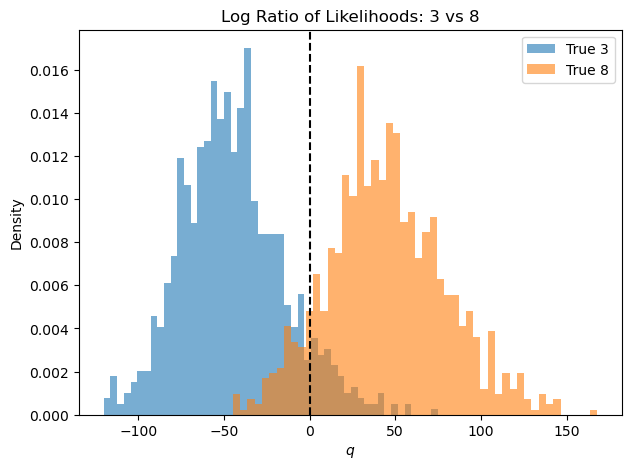

In [37]:
plt.figure(figsize=(7,5))

### YOUR CODE HERE
plt.hist(
    llr[y==3],
    bins=50,
    density=True,
    alpha=0.6,
    label="True 3"
)

plt.hist(
    llr[y==8],
    bins=50,
    density=True,
    alpha=0.6,
    label="True 8"
)

plt.axvline(0, color="black", ls="--")

plt.xlabel(r"$q$")
plt.ylabel("Density")
plt.title("Log Ratio of Likelihoods: 3 vs 8")
plt.legend()

plt.show()

Now let us try to put a threshold on this plot. You can see two distinct distributions, how where should we put the cut to decide which one is a $3$ and which one is $8$? Well if you put it at a negative value you'll gain purity in $3$ but also risk misclassification for $8$, and vice versa for positive valued cut. In fact this dilemma is often encounted in high energy physics where we want pure signals without losing too many signal events. In other words if you vary the cut threshold across $q$ from negative to positive, you'll see the false positives (Type-I error) rate falling monotonically with the true positives (power) rate. 

Now given a specific operating point (choice of threshold) the Neyman-Pearson lemma guarantees us that the likelihood ratios test has the highest power. If we look at ideal likelihoods, this statement is simpler to understand (think of the ideal likelihood as the closest approach to a Dirac Delta). Such distributions would encode the maximum information, and their log ratio is simply like a distance between two distributions/functions in the log likelihood space. Now for this ideal distribution,

$$q = \log\delta(x-\mu_1) - \log\delta(x-\mu_0) = \lim_{\sigma\to 0} \left[\frac{(x-\mu_1)^2}{\sigma^2}-\frac{(x-\mu_0)^2}{\sigma^2}\right]\to\infty$$
 Here, some other test statistics can perhaps have a similar acceptance region, but it will never be better than this. 
 
 Thus your next task is to verify the Neyman-Pearson lemma by comparing the log ratio of likelihoods (LLR) with the log ratio of log likelihoods and the sum of active pixels as test statistics.

### Test Statistics: Log Ratio of Log Likelihoods

In the next two blocks first calculate the log ratio of log likelihood and then plot it as before.

In [ ]:
# Name your test statistics variable ratio_ll
### YOUR CODE HERE
ratio_ll = torch.log(ll[:,8] / ll[:,3])

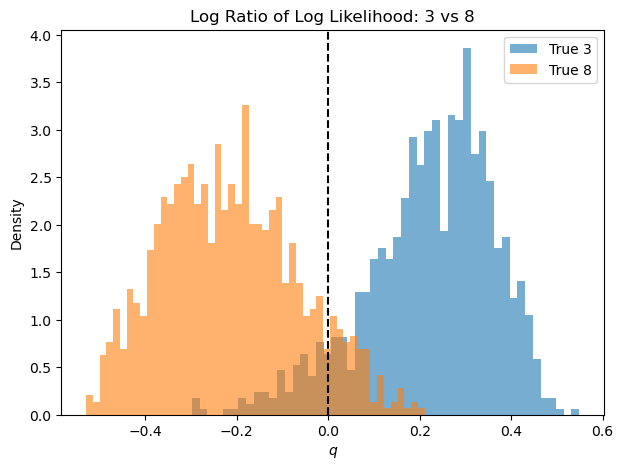

In [39]:
plt.figure(figsize=(7,5))

### YOUR CODE HERE
plt.hist(
    ratio_ll[y==3],
    bins=50,
    density=True,
    alpha=0.6,
    label="True 3"
)

plt.hist(
    ratio_ll[y==8],
    bins=50,
    density=True,
    alpha=0.6,
    label="True 8"
)

plt.axvline(0, color="black", ls="--")

plt.xlabel(r"$q$")
plt.ylabel("Density")
plt.title("Log Ratio of Log Likelihood: 3 vs 8")
plt.legend()

plt.show()

### Test Statistics: Active Pixels

In the next block, for every image, calculate the total number of active pixels and make the test statistics.

In [ ]:
active_pixels = []
for images, _ in tqdm(test_loader):
    ### YOUR CODE HERE
    active_pixels.append(torch.round(images).sum(dim=(1,2,3)))
active_pixels = torch.cat(active_pixels)

# Now keep only those images which have labels 3 and 8. The corresponding active pixel sum is your test statistics
# name your test statistics variable as active_pix_ts
### YOUR CODE HERE
mask = (labels == 3) | (labels == 8)
active_pix_ts = active_pixels[mask]

100%|██████████| 20/20 [00:04<00:00,  4.29it/s]


Plot the active pixel test statistics like before for both true 3 and 8 separately.

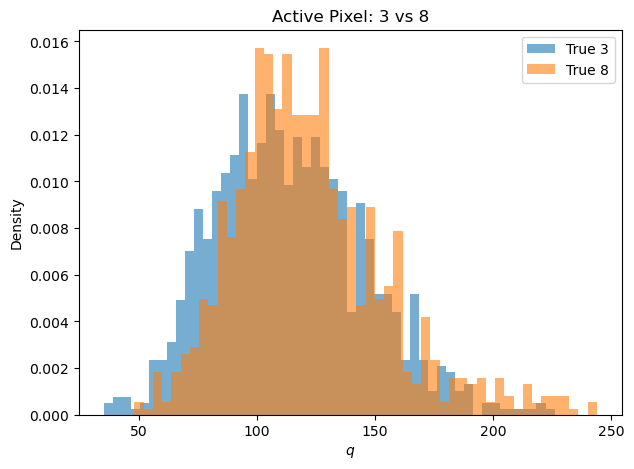

In [41]:
plt.figure(figsize=(7,5))

### YOUR CODE HERE
plt.hist(
    active_pix_ts[y==3],
    bins=50,
    density=True,
    alpha=0.6,
    label="True 3"
)

plt.hist(
    active_pix_ts[y==8],
    bins=50,
    density=True,
    alpha=0.6,
    label="True 8"
)

plt.xlabel(r"$q$")
plt.ylabel("Density")
plt.title("Active Pixel: 3 vs 8")
plt.legend()

plt.show()

### Neyman-Pearson Tradeoff

You will notice firstly that the ordering of the distribution is no longer monotonic for log likelihood ratio, and secondly the active pixel distribution has very poor separation for test statistics. In fact there is a better way to show this by directly plotting the mean of the false positive with that of the true positives. In the next code block calculate it for LLR.

In [46]:
thresholds_likelihood_ratio = torch.linspace(llr.min(), llr.max(), 200)

alpha_likelihood_ratio = []
power_likelihood_ratio = []

for t in thresholds_likelihood_ratio:
    ### YOUR CODE HERE

    false_positive = (llr[y == 3] > t).float().mean()

    true_positive = (llr[y == 8] > t).float().mean()

    alpha_likelihood_ratio.append(false_positive.item())
    power_likelihood_ratio.append(true_positive.item())

Now calculate it for log ratio of log likelihood.

In [47]:
thresholds_log_likelihood_ratio = torch.linspace(ratio_ll.min(), ratio_ll.max(), 200)

alpha_log_likelihood_ratio = []
power_log_likelihood_ratio = []

for t in thresholds_log_likelihood_ratio:
    ### YOUR CODE HERE

    false_positive = (ratio_ll[y == 3] > t).float().mean()

    true_positive = (ratio_ll[y == 8] > t).float().mean()

    alpha_log_likelihood_ratio.append(false_positive.item())
    power_log_likelihood_ratio.append(true_positive.item())

Then calculate it for active pixel test statistics.

In [48]:
thresholds_active_pix = torch.linspace(active_pix_ts.min(), active_pix_ts.max(), 200)

alpha_active_pix = []
power_active_pix = []

for t in thresholds_active_pix:
    ### YOUR CODE HERE

    false_positive = (active_pix_ts[y == 3] > t).float().mean()

    true_positive = (active_pix_ts[y == 8] > t).float().mean()

    alpha_active_pix.append(false_positive.item())
    power_active_pix.append(true_positive.item())

If everything is correct you should be able to plot the ROC curves to see that indeed the likelihood ratio is a better test statistics than log likelihood ratio and active pixels.

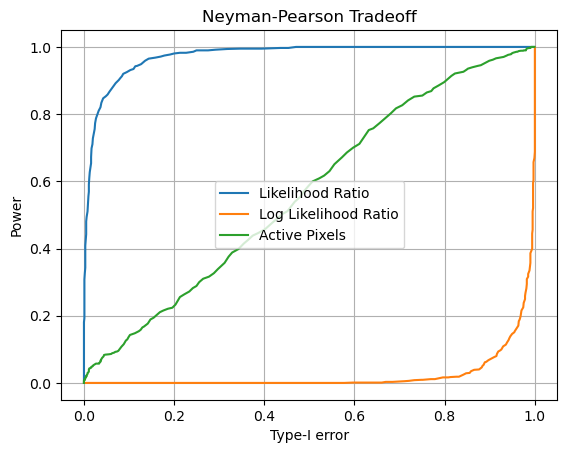

In [49]:
plt.plot(alpha_likelihood_ratio, power_likelihood_ratio, label='Likelihood Ratio')
plt.plot(alpha_log_likelihood_ratio, power_log_likelihood_ratio, label='Log Likelihood Ratio')
plt.plot(alpha_active_pix, power_active_pix, label='Active Pixels')

plt.xlabel("Type-I error")
plt.ylabel("Power")
plt.title("Neyman-Pearson Tradeoff")
plt.legend()
plt.grid()

plt.show()

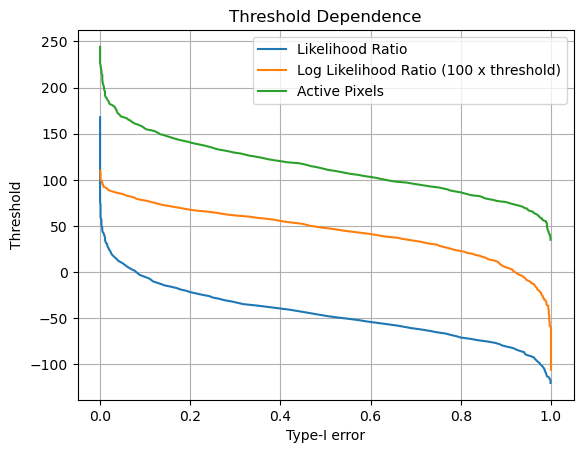

In [65]:
plt.plot(alpha_likelihood_ratio, thresholds_likelihood_ratio, label='Likelihood Ratio')
plt.plot(alpha_log_likelihood_ratio, 200*thresholds_log_likelihood_ratio, label='Log Likelihood Ratio (100 x threshold)')
plt.plot(alpha_active_pix, thresholds_active_pix, label='Active Pixels')

plt.xlabel("Type-I error")
plt.ylabel("Threshold")
plt.title("Threshold Dependence")
plt.legend()
plt.grid()

plt.show()